# Verify YOLO joints and action labels

Use this notebook after running `build_action_joint_dataset.py`. It overlays the saved YOLO skeleton on the original CFR video frame and shows the assigned action class.

The browser uses the saved CSV coordinates rather than running YOLO again, so what you see is exactly what will be used by the training dataset.

## 1. Generate the dataset if needed

Run this from the repository root in a terminal:

```powershell
conda run -n muay-thai python dataset\build_action_joint_dataset.py
```

Existing CSV files are skipped. Add `--overwrite` when you intentionally want to regenerate them.

In [1]:
from pathlib import Path

import cv2
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dataset").is_dir() and (candidate / "models").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Muay-ThAI repository root")


ROOT_DIR = find_repository_root(Path.cwd().resolve())
JOINTS_DIR = ROOT_DIR / "dataset" / "jointswithactionlabels"
VIDEO_DIR = ROOT_DIR / "media" / "videos" / "30fps"

print(f"Repository: {ROOT_DIR}")
print(f"Joint CSVs: {JOINTS_DIR}")
print(f"Videos:     {VIDEO_DIR}")

Repository: C:\Users\jjaramil\OneDrive - InterSystems Corporation\Documents\Muay-ThAI
Joint CSVs: C:\Users\jjaramil\OneDrive - InterSystems Corporation\Documents\Muay-ThAI\dataset\jointswithactionlabels
Videos:     C:\Users\jjaramil\OneDrive - InterSystems Corporation\Documents\Muay-ThAI\media\videos\30fps


In [2]:
csv_paths = sorted(JOINTS_DIR.glob("*_joints_labels.csv"))
if not csv_paths:
    raise FileNotFoundError(
        f"No joint CSV files found in {JOINTS_DIR}. "
        "Run dataset/build_action_joint_dataset.py first."
    )

frames = pd.concat(
    [pd.read_csv(path) for path in csv_paths],
    ignore_index=True,
)
frames = frames.sort_values(["video_id", "frame_index"]).reset_index(drop=True)

duplicate_rows = frames.duplicated(["video_id", "frame_index"]).sum()
if duplicate_rows:
    raise ValueError(f"Found {duplicate_rows} duplicate video/frame rows")

print(f"Loaded {len(frames):,} frames from {len(csv_paths)} CSV files")
display(frames.head(3))

Loaded 16,176 frames from 3 CSV files


,task_id,video_id,frame_index,label_frame,time_seconds,action_label,pose_detected,people_detected,selected_person_index,bbox_confidence,...,left_knee_confidence,right_knee_x,right_knee_y,right_knee_confidence,left_ankle_x,left_ankle_y,left_ankle_confidence,right_ankle_x,right_ankle_y,right_ankle_confidence
0,2,20260728_095722_30fps,0,1,0.000000,background,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,20260728_095722_30fps,1,2,0.033333,background,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,20260728_095722_30fps,2,3,0.066667,background,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Dataset summary

`missing_poses` is worth checking after a complete extraction. Background frames may legitimately have no person, but long gaps inside an action segment usually need inspection.

In [3]:
summary = (
    frames.groupby("video_id")
    .agg(
        frames=("frame_index", "nunique"),
        first_frame=("frame_index", "min"),
        last_frame=("frame_index", "max"),
        detected_poses=("pose_detected", "sum"),
    )
)
summary["missing_poses"] = summary["frames"] - summary["detected_poses"]
summary["missing_pose_percent"] = (
    100 * summary["missing_poses"] / summary["frames"]
).round(2)

display(summary)
display(
    frames.groupby(["video_id", "action_label"])
    .size()
    .rename("frames")
    .unstack(fill_value=0)
)

,frames,first_frame,last_frame,detected_poses,missing_poses,missing_pose_percent
video_id,,,,,,
20260728_095722_30fps,3238,0,3237,3037,201,6.21
20260728_095912_30fps,4242,0,4241,4220,22,0.52
20260728_130155_30fps,8696,0,8695,8571,125,1.44


action_label,background,guard_down,guard_up
video_id,,,
20260728_095722_30fps,303,1402,1533
20260728_095912_30fps,131,1630,2481
20260728_130155_30fps,165,6187,2344


## 3. Interactive skeleton viewer

- Choose a video and move the frame slider.
- Increase the confidence threshold to hide uncertain joints.
- Empty skeletons are displayed normally so missing detections remain visible.
- The title and frame overlay show the saved manual action class.

In [4]:
JOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
]

SKELETON_EDGES = [
    ("nose", "left_eye"),
    ("nose", "right_eye"),
    ("left_eye", "left_ear"),
    ("right_eye", "right_ear"),
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_elbow"),
    ("left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow"),
    ("right_elbow", "right_wrist"),
    ("left_shoulder", "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"),
    ("left_knee", "left_ankle"),
    ("right_hip", "right_knee"),
    ("right_knee", "right_ankle"),
]

CLASS_COLORS = {
    "guard_up": (40, 200, 40),
    "guard_down": (230, 50, 50),
    "background": (150, 150, 150),
    "punch": (50, 100, 240),
    "elbow": (245, 150, 40),
    "kick": (170, 60, 220),
    "knee": (220, 80, 180),
}


def read_video_frame(video_id: str, frame_index: int) -> np.ndarray:
    video_path = VIDEO_DIR / f"{video_id}.mp4"
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f"Could not open {video_path}")

    capture.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    success, frame_bgr = capture.read()
    capture.release()
    if not success:
        raise ValueError(f"Could not decode {video_id} frame {frame_index}")
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


def draw_saved_pose(
    image: np.ndarray,
    row: pd.Series,
    confidence_threshold: float,
) -> np.ndarray:
    output = image.copy()
    height, width = output.shape[:2]
    action_label = str(row["action_label"])
    color = CLASS_COLORS.get(action_label, (255, 200, 0))
    points = {}

    for joint_name in JOINT_NAMES:
        confidence = row.get(f"{joint_name}_confidence", np.nan)
        x = row.get(f"{joint_name}_x", np.nan)
        y = row.get(f"{joint_name}_y", np.nan)
        if pd.isna(confidence) or pd.isna(x) or pd.isna(y):
            continue
        if float(confidence) < confidence_threshold:
            continue
        point = (
            int(np.clip(float(x), 0, 1) * (width - 1)),
            int(np.clip(float(y), 0, 1) * (height - 1)),
        )
        points[joint_name] = point

    for start_name, end_name in SKELETON_EDGES:
        if start_name in points and end_name in points:
            cv2.line(output, points[start_name], points[end_name], color, 3)
    for point in points.values():
        cv2.circle(output, point, 5, (255, 255, 255), -1)
        cv2.circle(output, point, 5, color, 2)

    if not pd.isna(row.get("bbox_x1", np.nan)):
        x1 = int(np.clip(float(row["bbox_x1"]), 0, 1) * (width - 1))
        y1 = int(np.clip(float(row["bbox_y1"]), 0, 1) * (height - 1))
        x2 = int(np.clip(float(row["bbox_x2"]), 0, 1) * (width - 1))
        y2 = int(np.clip(float(row["bbox_y2"]), 0, 1) * (height - 1))
        cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

    status = "pose detected" if int(row["pose_detected"]) else "NO POSE"
    text = (
        f"{action_label} | frame {int(row['label_frame'])} "
        f"| {status} | people {int(row['people_detected'])}"
    )
    cv2.rectangle(output, (0, 0), (min(width, 900), 48), (0, 0, 0), -1)
    cv2.putText(
        output,
        text,
        (12, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        color,
        2,
        cv2.LINE_AA,
    )
    return output


def show_pose_frame(
    video_id: str,
    frame_index: int,
    confidence_threshold: float = 0.25,
) -> None:
    matching = frames[
        (frames["video_id"] == video_id)
        & (frames["frame_index"] == int(frame_index))
    ]
    if matching.empty:
        print(f"No dataset row for {video_id}, frame {frame_index}")
        return

    row = matching.iloc[0]
    image = read_video_frame(video_id, int(frame_index))
    overlay = draw_saved_pose(image, row, confidence_threshold)

    plt.figure(figsize=(14, 8))
    plt.imshow(overlay)
    plt.title(
        f"{video_id} — frame_index={int(frame_index)}, "
        f"class={row['action_label']}"
    )
    plt.axis("off")
    plt.show()

In [5]:
video_ids = sorted(frames["video_id"].unique())
video_widget = widgets.Dropdown(
    options=video_ids,
    value=video_ids[0],
    description="Video:",
    layout=widgets.Layout(width="600px"),
)


def frame_bounds(video_id: str) -> tuple[int, int]:
    video_frames = frames.loc[frames["video_id"] == video_id, "frame_index"]
    return int(video_frames.min()), int(video_frames.max())


initial_min, initial_max = frame_bounds(video_widget.value)
frame_widget = widgets.IntSlider(
    value=initial_min,
    min=initial_min,
    max=initial_max,
    step=1,
    description="Frame:",
    continuous_update=False,
    layout=widgets.Layout(width="900px"),
)
confidence_widget = widgets.FloatSlider(
    value=0.25,
    min=0.0,
    max=1.0,
    step=0.05,
    description="Joint conf:",
    continuous_update=False,
    readout_format=".2f",
    layout=widgets.Layout(width="500px"),
)


def update_frame_slider(change) -> None:
    minimum, maximum = frame_bounds(change["new"])
    frame_widget.min = minimum
    frame_widget.max = maximum
    frame_widget.value = minimum


video_widget.observe(update_frame_slider, names="value")
viewer_output = widgets.interactive_output(
    show_pose_frame,
    {
        "video_id": video_widget,
        "frame_index": frame_widget,
        "confidence_threshold": confidence_widget,
    },
)

display(widgets.VBox([video_widget, frame_widget, confidence_widget]), viewer_output)

Output()

## 4. Review samples from one class

This view chooses evenly spaced examples rather than random examples, making repeated checks reproducible.

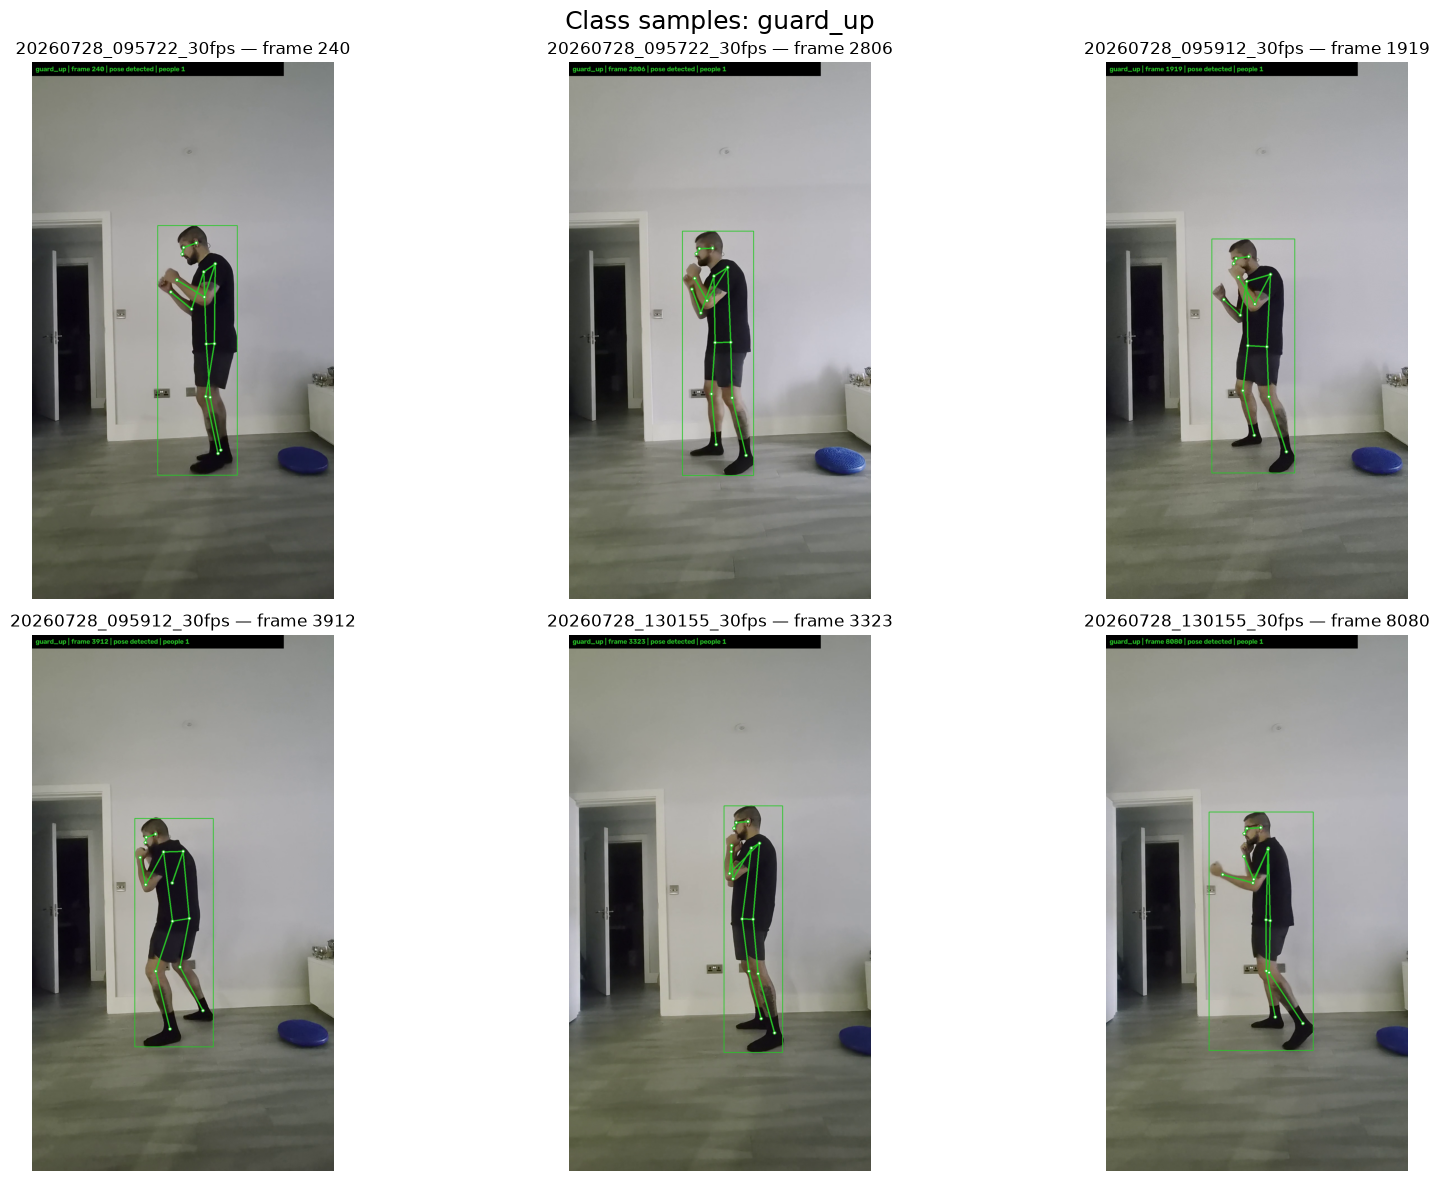

In [9]:
def show_class_samples(
    action_label: str,
    video_id: str | None = None,
    sample_count: int = 6,
    confidence_threshold: float = 0.25,
) -> None:
    candidates = frames[frames["action_label"] == action_label]
    if video_id is not None:
        candidates = candidates[candidates["video_id"] == video_id]
    if candidates.empty:
        print("No matching frames")
        return

    positions = np.linspace(
        0,
        len(candidates) - 1,
        min(sample_count, len(candidates)),
        dtype=int,
    )
    selected = candidates.iloc[positions]
    columns = 3
    rows = int(np.ceil(len(selected) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(18, 6 * rows))
    axes = np.atleast_1d(axes).ravel()

    for axis, (_, row) in zip(axes, selected.iterrows()):
        image = read_video_frame(row["video_id"], int(row["frame_index"]))
        overlay = draw_saved_pose(image, row, confidence_threshold)
        axis.imshow(overlay)
        axis.set_title(f"{row['video_id']} — frame {int(row['label_frame'])}")
        axis.axis("off")
    for axis in axes[len(selected):]:
        axis.axis("off")

    figure.suptitle(f"Class samples: {action_label}", fontsize=18)
    figure.tight_layout()
    plt.show()


# Example: show six guard-up frames across the complete dataset.
show_class_samples("guard_up", sample_count=6)

## Manual review checklist

Pay particular attention to:

1. Class transitions: inspect frames immediately before and after each change between `guard_up`, `guard_down`, and `background`.
2. Subject selection: confirm the bounding box follows the intended athlete when multiple people are visible.
3. Pose failures: look for missing or low-confidence wrists, elbows, and shoulders during fast movement.
4. Temporal consistency: watch for the skeleton suddenly jumping to another person.
5. Missing poses inside action segments: these are more concerning than missing poses in `background`.